# Function Transformer

`15_Feature_Scaling.ipynb` and `16_Feature_Scaling_Normalization.ipynb`
changed the **range** of a column (squeeze it into 0–1, or center it
around 0). This notebook changes the **shape** of a column instead.

A `FunctionTransformer` is a small sklearn wrapper. You give it any
function, and it applies that function to every value in a column. It
works the same way as the other sklearn tools you already used
(`fit`, then `transform`) — the only difference is *you* write the
function.

Why would we want to change the shape of a column? Many models work
best when a column looks like a normal distribution (a symmetric,
bell-shaped curve). `CoapplicantIncome` does not look like that at all —
most people have a low or zero co-applicant income, and a few have a
very high one. That long tail on the right is called **right skew**
(also "positive skew"). This notebook tries different functions to fix
that shape, and looks closely at one case where the fix makes things
*worse*, not better — and why.

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dataset = pd.read_csv("loans.csv")

In [3]:
dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               6
Dependents           15
Education             9
Self_Employed        32
ApplicantIncome       2
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     21
Credit_History       50
Property_Area         9
Loan_Status           0
dtype: int64

`CoapplicantIncome` has `0` missing values — nothing to fill in here.
Good, because that means anything we see in the shape of this column is
about real data, not about missing-value gaps.

/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_36888/1899262194.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["CoapplicantIncome"])


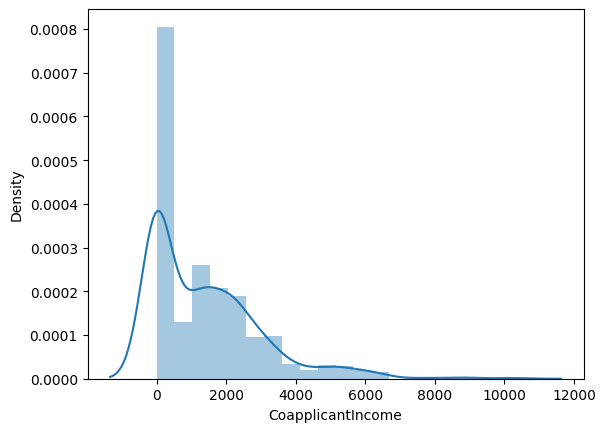

In [4]:
sns.distplot(dataset["CoapplicantIncome"])
plt.show()

In [5]:
dataset["CoapplicantIncome"].skew()

np.float64(1.5399420730801827)

The picture above is **non-normal**. It has a tall spike near `0` and a
long tail stretching right, out past `6000`. `.skew()` puts a number on
that shape:

- `0` means perfectly symmetric (a normal curve).
- A positive number means the tail is on the **right** (right skew).
- A negative number means the tail is on the **left** (left skew).

Here `.skew()` is about **`1.54`** — clearly right-skewed, matching what
the picture shows. We will use this number again and again below, to
check whether each transform actually helps or not — not just by
eyeballing the picture.

One common first step before transforming a skewed column is to remove
outliers — the few extreme values that stretch the tail out so far. The
same IQR method from `13_Outlier_Removal_IQR.ipynb` finds the cutoff
below.

In [6]:
q1 = dataset["CoapplicantIncome"].quantile(0.25)
q3 = dataset["CoapplicantIncome"].quantile(0.75)
iqr = q3-q1
iqr

np.float64(2217.75)

In [7]:
min_r = q1-(1.5*iqr)
max_r = q3+(1.5*iqr)

In [8]:
min_r, max_r

(np.float64(-3326.625), np.float64(5544.375))

## Example 1 — Remove Outliers First, Then Transform

Any row with `CoapplicantIncome` above `max_r` gets dropped. Then we
will apply a transform to what's left.

In [9]:
dataset = dataset[dataset["CoapplicantIncome"]<=max_r]

In [10]:
dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001001,Male,Yes,0,Not Graduate,No,1686.0,1020,80.0,360.0,1.0,Semiurban,Y
1,LP001002,Male,Yes,0,Not Graduate,No,2437.0,1201,122.0,360.0,1.0,Urban,Y
2,LP001003,Female,No,0,Graduate,No,8313.0,1065,319.0,360.0,1.0,Urban,Y
3,LP001004,Male,Yes,0,Graduate,No,5069.0,0,218.0,360.0,1.0,Semiurban,Y
4,LP001005,Male,No,2,Graduate,No,3002.0,2283,194.0,360.0,0.0,Urban,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
613,LP001614,Female,Yes,2,Graduate,No,3153.0,0,114.0,360.0,0.0,Rural,N
614,LP001615,Male,Yes,NaN,Graduate,No,3995.0,1736,215.0,360.0,1.0,Urban,Y
615,LP001616,Male,No,2,Graduate,No,3916.0,4134,250.0,360.0,0.0,Semiurban,N
616,LP001617,Male,Yes,0,Graduate,No,2366.0,0,101.0,360.0,1.0,Semiurban,Y


/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_36888/1899262194.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["CoapplicantIncome"])


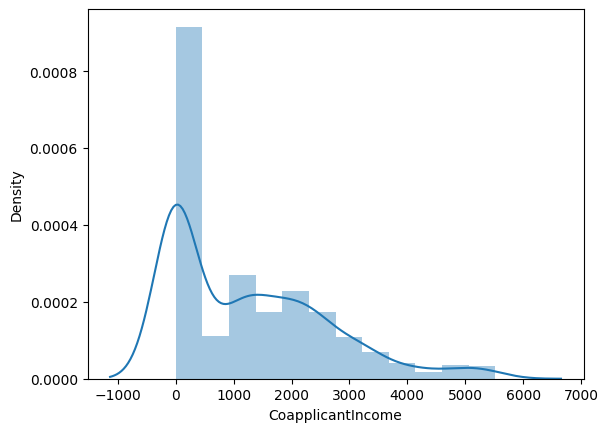

In [11]:
sns.distplot(dataset["CoapplicantIncome"])
plt.show()

In [12]:
dataset["CoapplicantIncome"].skew()

np.float64(0.9655444212412013)

Skew dropped from `1.54` to about **`0.97`** — removing `15` outlier rows
(`618 → 603`) helped, but only cut the skew by about a third. The picture
still leans right, just a little less far. Outlier removal alone did not
make this column normal. We still need a transform.

In [13]:
from sklearn.preprocessing import FunctionTransformer

The function we try first is `np.log1p`. It means "log of (x + 1)."

Two things to know about it, in plain terms:

- **Log makes big numbers much smaller, but small numbers only a
  little smaller.** That's exactly what a right-skewed column needs —
  pull the few huge values down close to the rest, without squashing
  the small values too.
- **The `+ 1` part matters.** Plain `log(0)` is undefined (you can't
  take the log of zero). `CoapplicantIncome` has plenty of `0` rows, so
  plain `np.log` would crash. `log1p(x) = log(x + 1)` sidesteps that:
  `log1p(0) = log(1) = 0`.

In [14]:
ft = FunctionTransformer(func=np.log1p)
ft.fit(dataset["CoapplicantIncome"])


,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<ufunc 'log1p'>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None
,"inv_kw_args inv_kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to inverse_func... versionadded:: 0.18",None


In [15]:
dataset["CoapplicantIncome_tf"]=ft.transform(dataset["CoapplicantIncome"])


/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_36888/1020236315.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["CoapplicantIncome"])
/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_36888/1020236315.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["C

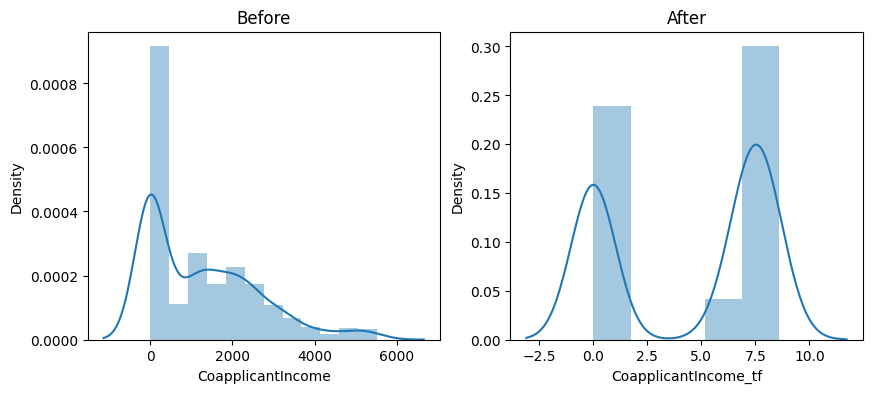

In [16]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.distplot(dataset["CoapplicantIncome"])
plt.title("Before")

plt.subplot(1,2,2)
sns.distplot(dataset["CoapplicantIncome_tf"])
plt.title("After")

plt.show()

In [17]:
dataset["CoapplicantIncome"].skew(), dataset["CoapplicantIncome_tf"].skew()

(np.float64(0.9655444212412013), np.float64(-0.32165545273566626))

Skew went from `0.97` to about **`-0.32`** — much closer to `0` (a small
negative number now, almost flat). The "After" picture backs this up: the
spike near `0` is gone, and the shape now looks close to a normal curve.
Log did its job.

## Example 2 — Same Log Transform, Without Removing Outliers First

You asked a fair question: what if we skip the outlier-removal step
completely, and run `log1p` straight on the original, untouched column?
Let's actually try it, instead of guessing. We load a fresh copy of the
data so the outlier removal above doesn't affect this example.

In [18]:
dataset_raw = pd.read_csv("loans.csv")
dataset_raw["CoapplicantIncome"].skew()

np.float64(1.5399420730801827)

Same `1.54` as before — makes sense, this is the exact same raw column,
outliers and all. Now apply `log1p` directly to it, no filtering first.

In [19]:
ft2 = FunctionTransformer(func=np.log1p)
ft2.fit(dataset_raw[["CoapplicantIncome"]])

dataset_raw["CoapplicantIncome_tf"] = ft2.transform(dataset_raw["CoapplicantIncome"])

/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_36888/3115430268.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset_raw["CoapplicantIncome"])
/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_36888/3115430268.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(datase

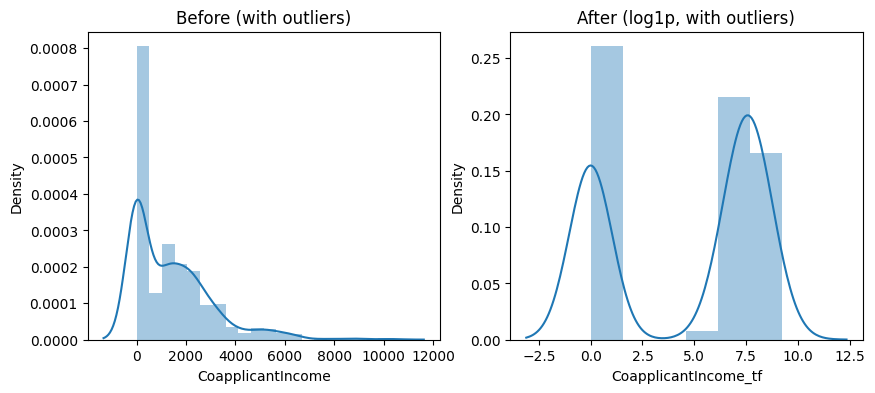

In [20]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.distplot(dataset_raw["CoapplicantIncome"])
plt.title("Before (with outliers)")

plt.subplot(1, 2, 2)
sns.distplot(dataset_raw["CoapplicantIncome_tf"])
plt.title("After (log1p, with outliers)")

plt.show()

In [21]:
dataset_raw["CoapplicantIncome"].skew(), dataset_raw["CoapplicantIncome_tf"].skew()

(np.float64(1.5399420730801827), np.float64(-0.3558417035137675))

Skew went from `1.54` all the way to about **`-0.36`** — and that's
*without* removing a single row first. Compare the two log results:

| | Skew before log | Skew after log |
|---|---|---|
| Outliers removed first (Example 1) | `0.97` | `-0.32` |
| Outliers kept in (Example 2) | `1.54` | `-0.36` |

Both end up close to `0`, close to each other. This is a real finding,
not something to explain away: `log1p` is strong enough to pull in even
the biggest, untouched values on its own. Removing outliers first is
still a reasonable thing to do, but for this column it wasn't strictly
necessary before applying `log1p`.

## Example 3 — What Happens With Square (`x**2`)?

This is the one from your screenshot. Instead of `log1p`, use `x**2` —
multiply every value by itself. We'll use the outlier-removed `dataset`
from Example 1, so the numbers line up with what you saw.

In [22]:
ft3 = FunctionTransformer(func=lambda x: x**2)
ft3.fit(dataset[["CoapplicantIncome"]])

dataset["CoapplicantIncome_sq"] = ft3.transform(dataset["CoapplicantIncome"])

/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_36888/1102268995.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["CoapplicantIncome"])
/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_36888/1102268995.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["C

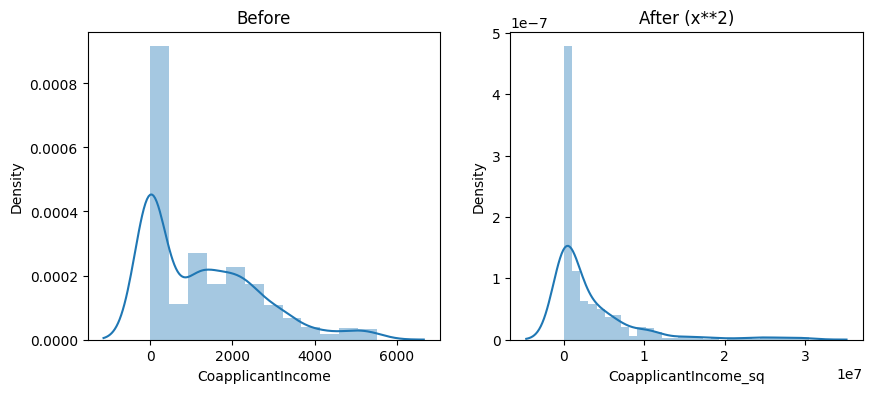

In [23]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.distplot(dataset["CoapplicantIncome"])
plt.title("Before")

plt.subplot(1, 2, 2)
sns.distplot(dataset["CoapplicantIncome_sq"])
plt.title("After (x**2)")

plt.show()

In [24]:
dataset["CoapplicantIncome"].max(), dataset["CoapplicantIncome_sq"].max()

(np.int64(5521), np.int64(30481441))

In [25]:
dataset["CoapplicantIncome"].skew(), dataset["CoapplicantIncome_sq"].skew()

(np.float64(0.9655444212412013), np.float64(2.6205982156525023))

This is why the "After" graph looks so strange.

**The biggest value exploded.** The largest `CoapplicantIncome` in this
data is about `5,521`. Squared, it becomes about `30,481,441` — over 30
million. That is why the x-axis on the right jumps to `1e7` (10 million)
and beyond. One line of code did that: `5521 ** 2 = 30,481,441`.

**Small values barely moved.** Most rows are small numbers, close to
`0`. Squaring a small number keeps it small (`10 ** 2 = 100`, still
tiny). So the big spike of small values near `0` stays almost exactly
where it was.

Put those two together: the small values are still bunched up near `0`,
but the few big values just flew off far to the right. The gap between
"most of the data" and "the extreme few" got much, much bigger, not
smaller. That's the tall thin spike plus the long, flat, almost-invisible
tail out to `3×10⁷` in the picture.

The skew number proves it went the wrong way: it went **up**, from
`0.97` to about **`2.62`** — more skewed than before, not less.

**Rule of thumb:**

| Column shape | Function that usually helps |
|---|---|
| Right-skewed (long tail on the right, like income) | `log`, `sqrt` — these pull big numbers down |
| Left-skewed (long tail on the left) | `square`, `cube` — these push big numbers up |

`CoapplicantIncome` is right-skewed, so `log1p` (Examples 1 and 2) was
the right tool, and `x**2` (this example) was the wrong one — on
purpose, so we could see what "wrong" actually looks like on a graph.

## Example 4 — Is `x*x` Different From `x**2`?

You noticed the graph looked different when you tried `x*x` instead of
`x**2`. Let's check directly, on the same data, in the same cell —
instead of guessing.

In [26]:
ft3b = FunctionTransformer(func=lambda x: x * x)
ft3b.fit(dataset[["CoapplicantIncome"]])

dataset["CoapplicantIncome_mul"] = ft3b.transform(dataset["CoapplicantIncome"])

In [27]:
(dataset["CoapplicantIncome_sq"] == dataset["CoapplicantIncome_mul"]).all()

np.True_

`True` — every single row matches. `x*x` and `x**2` are two different
ways of writing the exact same math: "multiply the number by itself."
There is no version of this data where they can give different graphs.

So if your two graphs looked different earlier, the function was not the
cause. The most likely reason: the two runs used different data — for
example, one used the outlier-removed `dataset`, the other used the
original data with outliers still in it (like Example 3 vs. how squaring
the raw column with a max of `10,288` would push the biggest value up to
about `105,842,944` instead of `30,481,441`). Same function, different
input, different-looking graph.

## Putting It All Together

One picture, three shapes side by side: the original column, the log
version, and the square version. Each title shows the skew number, so
you can compare all three at a glance instead of scrolling back up.

/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_36888/3976394420.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["CoapplicantIncome"], ax=axes[0], color="#8a8f98")
/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_36888/3976394420.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe57

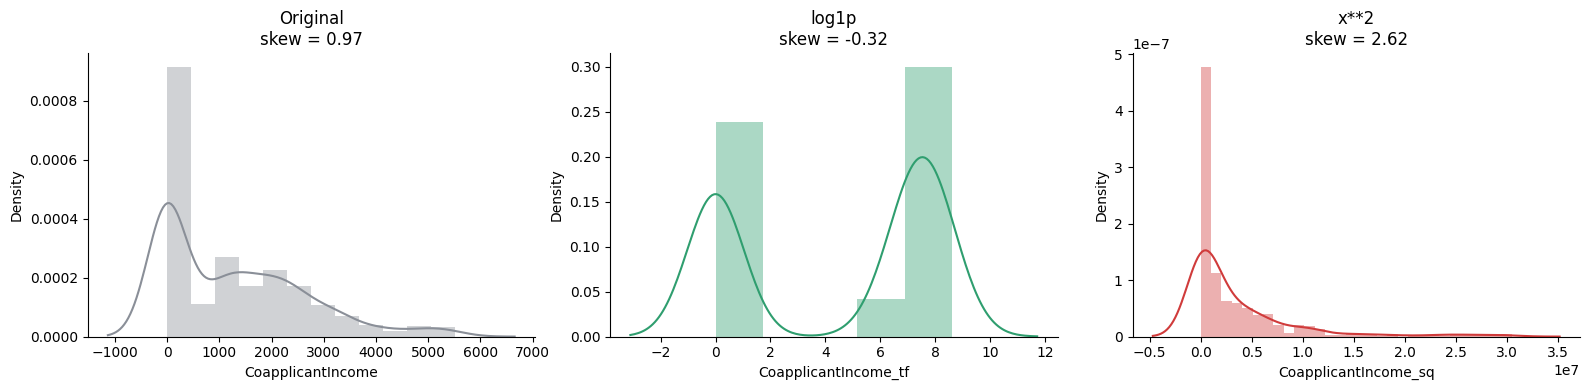

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.distplot(dataset["CoapplicantIncome"], ax=axes[0], color="#8a8f98")
axes[0].set_title(f"Original\nskew = {dataset['CoapplicantIncome'].skew():.2f}")

sns.distplot(dataset["CoapplicantIncome_tf"], ax=axes[1], color="#2f9e6f")
axes[1].set_title(f"log1p\nskew = {dataset['CoapplicantIncome_tf'].skew():.2f}")

sns.distplot(dataset["CoapplicantIncome_sq"], ax=axes[2], color="#d03b3b")
axes[2].set_title(f"x**2\nskew = {dataset['CoapplicantIncome_sq'].skew():.2f}")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

The middle chart is the closest to a normal, bell-shaped curve. The right
chart is the most skewed of all three, even more than the untouched
original on the left. One last chart: every skew number from this
notebook, side by side, with a red dashed line at `0` (perfectly
symmetric) to measure everything against.

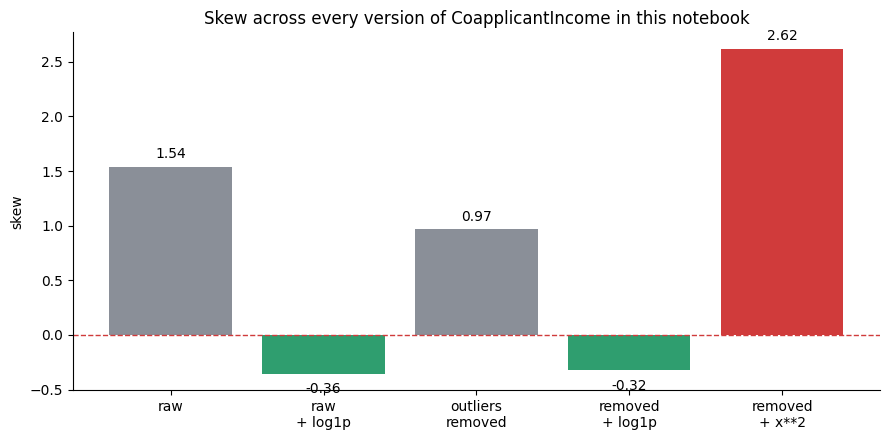

In [29]:
skew_values = {
    "raw": dataset_raw["CoapplicantIncome"].skew(),
    "raw\n+ log1p": dataset_raw["CoapplicantIncome_tf"].skew(),
    "outliers\nremoved": dataset["CoapplicantIncome"].skew(),
    "removed\n+ log1p": dataset["CoapplicantIncome_tf"].skew(),
    "removed\n+ x**2": dataset["CoapplicantIncome_sq"].skew(),
}

plt.figure(figsize=(9, 4.5))
bars = plt.bar(skew_values.keys(), skew_values.values(),
                color=["#8a8f98", "#2f9e6f", "#8a8f98", "#2f9e6f", "#d03b3b"])
plt.axhline(0, color="#d03b3b", linestyle="--", linewidth=1)
plt.ylabel("skew")
plt.title("Skew across every version of CoapplicantIncome in this notebook")
for b in bars:
    y = b.get_height()
    plt.text(b.get_x() + b.get_width() / 2, y + (0.08 if y >= 0 else -0.18),
              f"{y:.2f}", ha="center")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Summary

- `FunctionTransformer` lets you plug any function into the usual
  sklearn `fit` / `transform` pattern. You pick the function.
- `.skew()` gives a number for the shape of a column: `0` is symmetric,
  positive means a right tail, negative means a left tail. Use it to
  check a transform's result, not just the picture.
- `CoapplicantIncome` starts right-skewed (`skew = 1.54`). `log1p` fixes
  that well, whether or not outliers were removed first (`-0.32` with
  outliers removed, `-0.36` without). Removing outliers helped a little
  on its own (`1.54 → 0.97`), but `log1p` did most of the real work.
- `x**2` made things worse (`0.97 → 2.62`), because squaring barely
  moves small numbers but sends big numbers flying (`5,521 → 30,481,441`).
  Square and cube are tools for **left**-skewed data, not right-skewed
  data like this column.
- `x*x` and `x**2` are the same operation — checked directly, every row
  matched. A different-looking graph always means different input data,
  never a different function.

## FAQ

**1. In the simplest words, what does `FunctionTransformer` actually do?**
It runs a function on every value in a column. That's the whole thing.
You pick the function (`log1p`, `x**2`, or literally anything else). It
does not think, learn, or decide anything on its own — it just applies
your function, one value at a time, to the whole column.

**2. Other tools like `StandardScaler` learn something in `.fit()` (the
mean, the min, the max). What does `FunctionTransformer` learn?**
For a plain function like `log1p` or `x**2` — nothing. There is nothing
to learn: `log1p(5)` is always `log1p(5)`, no matter what the rest of
the column looks like. `.fit()` here is basically empty. It's still
there so `FunctionTransformer` has the same shape (`fit`, then
`transform`) as every other sklearn tool, which matters later when you
chain several tools together in a `Pipeline`.

**3. Then why not just write `dataset["col"] = np.log1p(dataset["col"])`
directly, and skip `FunctionTransformer` completely?**
For one column, in one notebook, that's genuinely simpler — and works
exactly the same. `FunctionTransformer` earns its place when you build a
`Pipeline`: a single sklearn object that bundles several steps together
(fill missing values → encode → transform → scale → model) so the exact
same steps replay automatically on new data later, without you retyping
every line by hand each time.

**4. In this notebook, `.fit()` sometimes gets `dataset["CoapplicantIncome"]`
(single brackets) and sometimes `dataset[["CoapplicantIncome"]]` (double
brackets). Does that matter?**
Single brackets pull out a **Series** — one column, treated as a flat
list of numbers. Double brackets pull out a **DataFrame** — a table,
even if that table only has one column in it. Checked directly: for a
simple function like `log1p`, `FunctionTransformer` works fine either
way, and just gives back the same shape you put in (Series in → Series
out, DataFrame in → DataFrame out). Double brackets is the safer habit,
because some other sklearn tools (not this one) *require* a table and
will error on a plain Series.

**5. Is this the same thing as Feature Scaling from `15_Feature_Scaling.ipynb`
and `16_Feature_Scaling_Normalization.ipynb`?**
No — different job. Scaling changes the **range** of numbers (for
example, squeeze everything into `0`–`1`) but keeps the same shape.
`FunctionTransformer` with `log1p` or `x**2` changes the **shape** of the
distribution (how skewed it is) but not the range in the same way. It's
common to do both: fix the shape first with a transform, then scale the
range.

**6. How do I pick a function for my own column, without a screenshot to
copy from?**
Two steps. First, plot it and run `.skew()`. If the number is already
close to `0`, you likely don't need a transform at all. If it's a big
positive number (right-skewed, long tail on the right — like
`CoapplicantIncome`), try `log` or `sqrt`. If it's a big negative number
(left-skewed, long tail on the left), try `square` or `cube`. Then
check `.skew()` again on the result — don't just trust the picture, let
the number confirm it.

**7. Does transforming a column ever add or remove rows?**
No. A transform changes the **value** inside each row, one number in,
one number out — the row count never changes. That's different from
outlier removal (Example 1's `dataset[dataset["CoapplicantIncome"] <= max_r]`
step), which does drop rows. Easy to mix the two up because they often
happen back to back, but they're separate operations.

**8. Can I undo a transform and get the original numbers back?**
Yes, if the function has an opposite. `log1p` can be undone with
`np.expm1` (its exact opposite). `FunctionTransformer` even has an
`inverse_func` argument for this — pass the undo-function in when you
create it, and call `.inverse_transform()` later. Square can be undone
with square-root, but only safely for numbers that were `0` or positive
to begin with.

**9. What if a column has negative numbers — can I still use `log1p`?**
Not safely. `log` of a negative number does not exist, so `log1p` on
negative values gives back `NaN` (not-a-number) instead of erroring
loudly, which can be an easy mistake to miss. `CoapplicantIncome` never
goes negative, so this notebook never hit the problem, but it's worth
checking `.min()` on any new column before reaching for `log1p`.